In [156]:
!pip install imbalanced-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
data = pd.read_csv("/content/creditcard 2.csv")

In [79]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [80]:
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

Rows: 284,807
Columns: 31


In [81]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [82]:
data.isnull().sum().sort_values(ascending=False)

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


THERE ARE ONLY ONE NULL VALUES IN EACH CLASS AND AMOUNT WHICH CAN BE EITHER IGNORED OR DELETED RATHER OF WHICH WILL NOT AFEFCT THE MODEL

In [10]:
data.dtypes

In [83]:
duplicates = data.duplicated().sum()
print(duplicates)

1081


##Duplicate transactions can bias the model if they are accidental duplicates.

In [84]:
data['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


## The Dataset is Imbalaced so eed to convert it to a balanced dataset for a good Model

###Data Cleaing

In [86]:
df = data.copy()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [85]:
df = df.dropna()


In [28]:
df.isnull().sum().sort_values(ascending=False)

In [87]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")


Duplicate rows: 1081


In [88]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [89]:
# Deleting duplicates such that it does not leed to the biasement of model
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [90]:
print(f"Before Duplicates: {data.shape}")
print(f"After Duplicates: {df.shape}")

Before Duplicates: (284807, 31)
After Duplicates: (283726, 31)


In [91]:
df.to_csv("creditcard_clean.csv", index=False)


#EDA

### TARGET VARIABLE (CLASS)

In [92]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.83329
1,0.16671


### Highly Imbalaunced Dataset

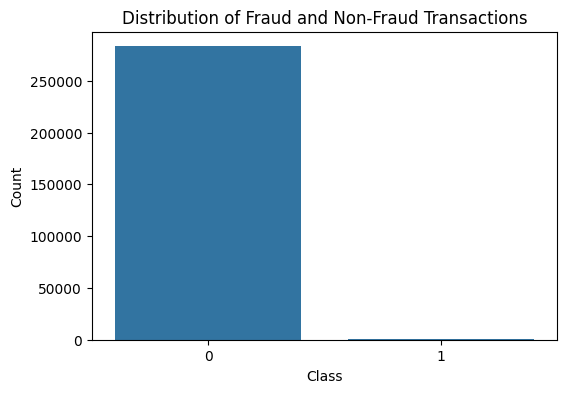

In [96]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Class')

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

## TRANSACTION AMOUNT


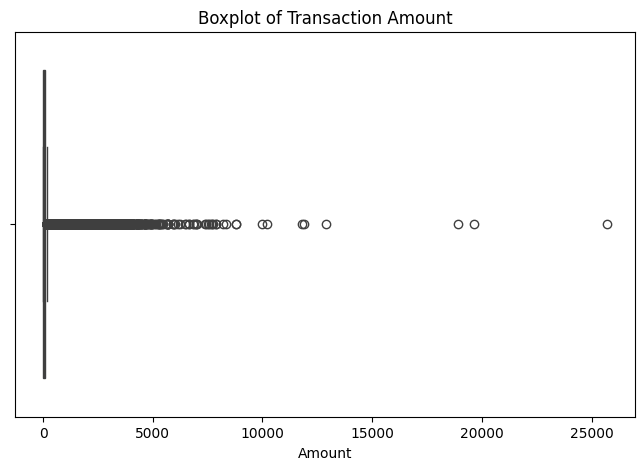

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Amount'])

plt.title("Boxplot of Transaction Amount")
plt.show()

### Analyzing Time

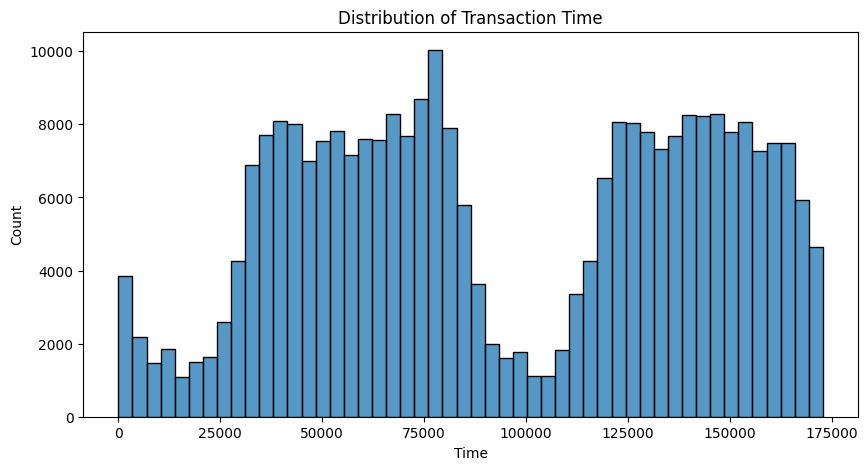

In [98]:
plt.figure(figsize=(10,5))
sns.histplot(df['Time'], bins=50)
plt.title("Distribution of Transaction Time")

plt.show()

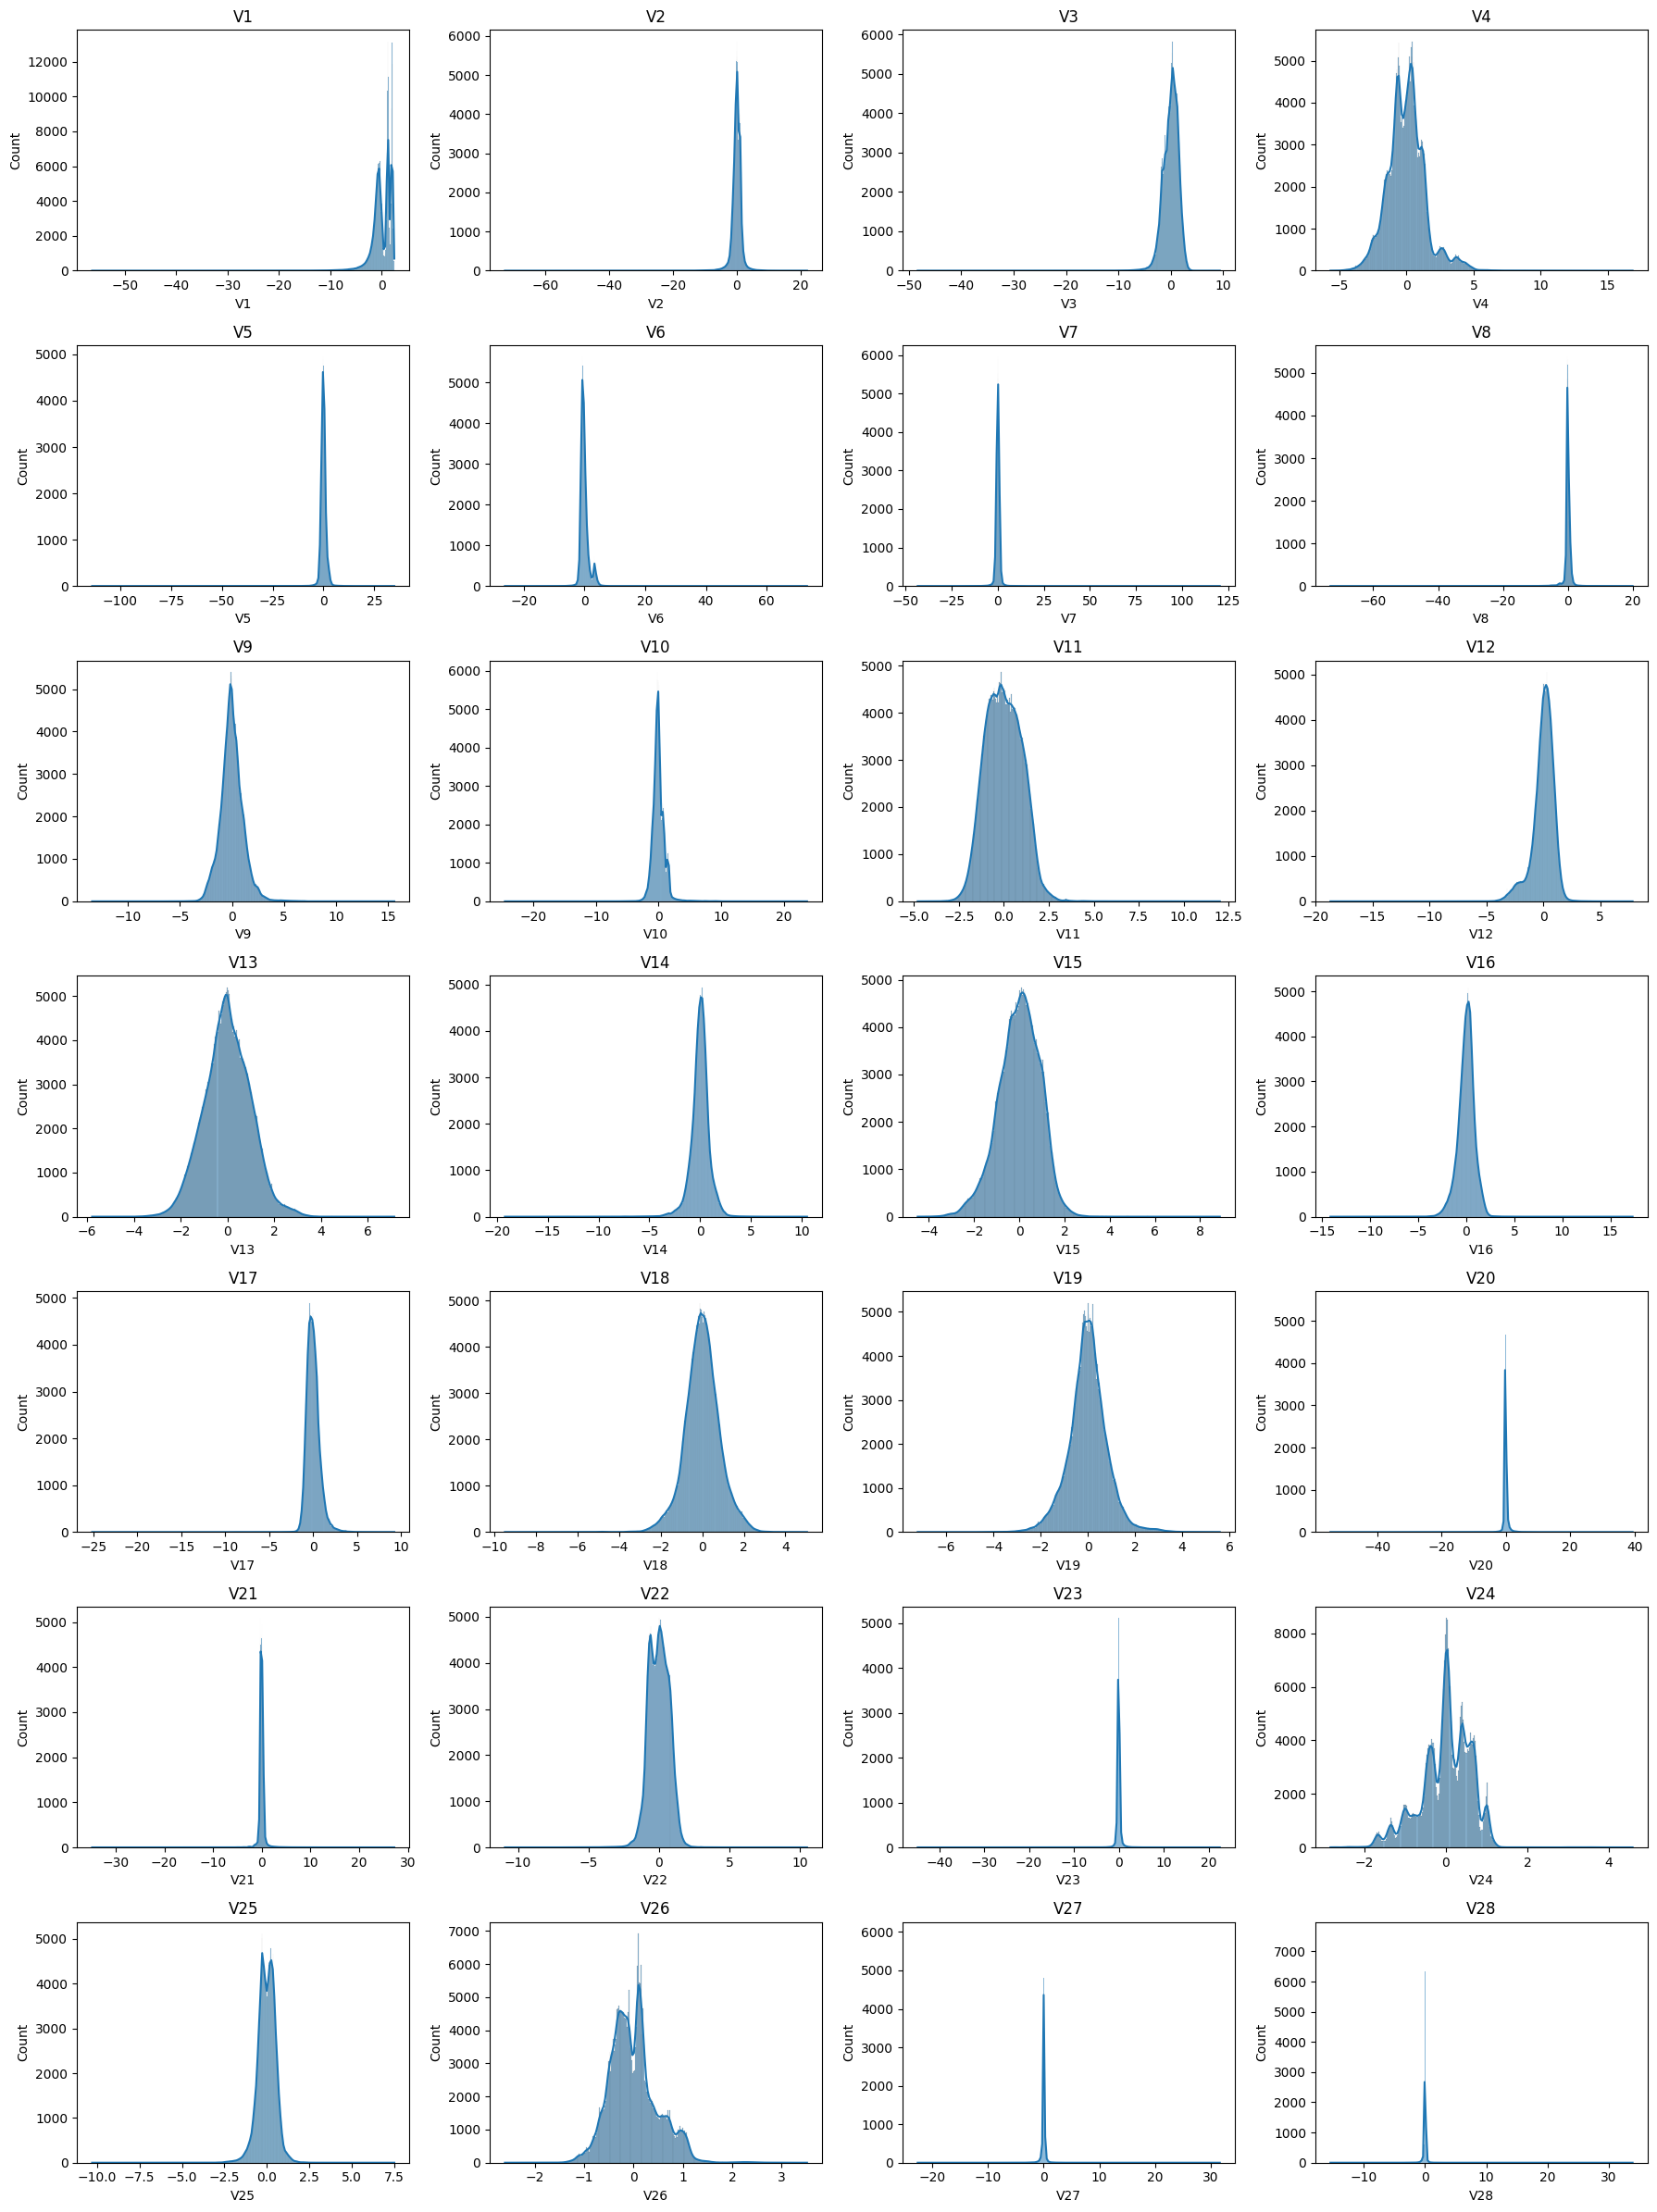

In [99]:
features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 24))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [60]:
# df.skew().sort_values(ascending=False)

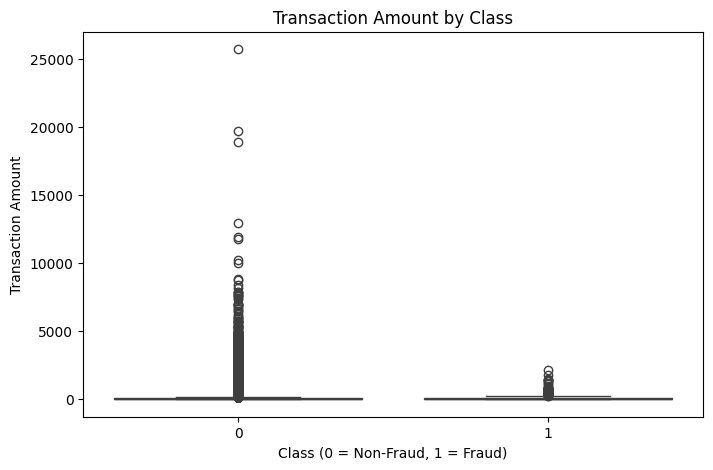

In [100]:
#Fraud vs Transaction Amount
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

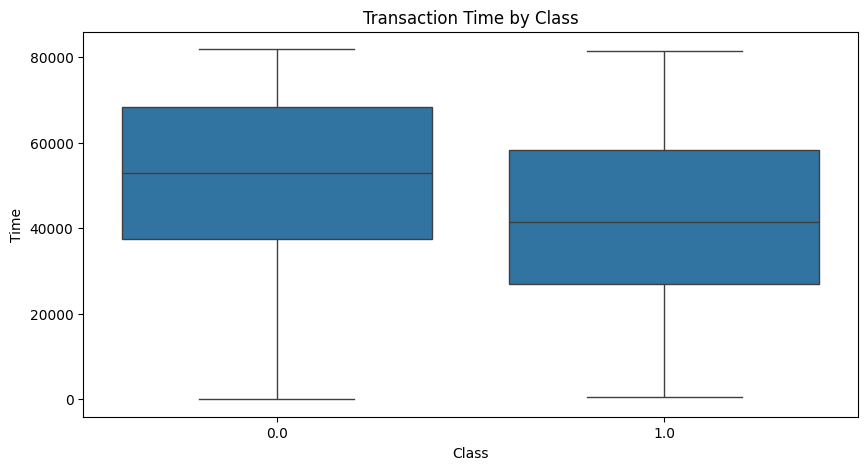

In [66]:
#Fraud vs Transaction Time
plt.figure(figsize=(10,5))

sns.boxplot(x='Class', y='Time', data=df)

plt.title("Transaction Time by Class")

plt.show()

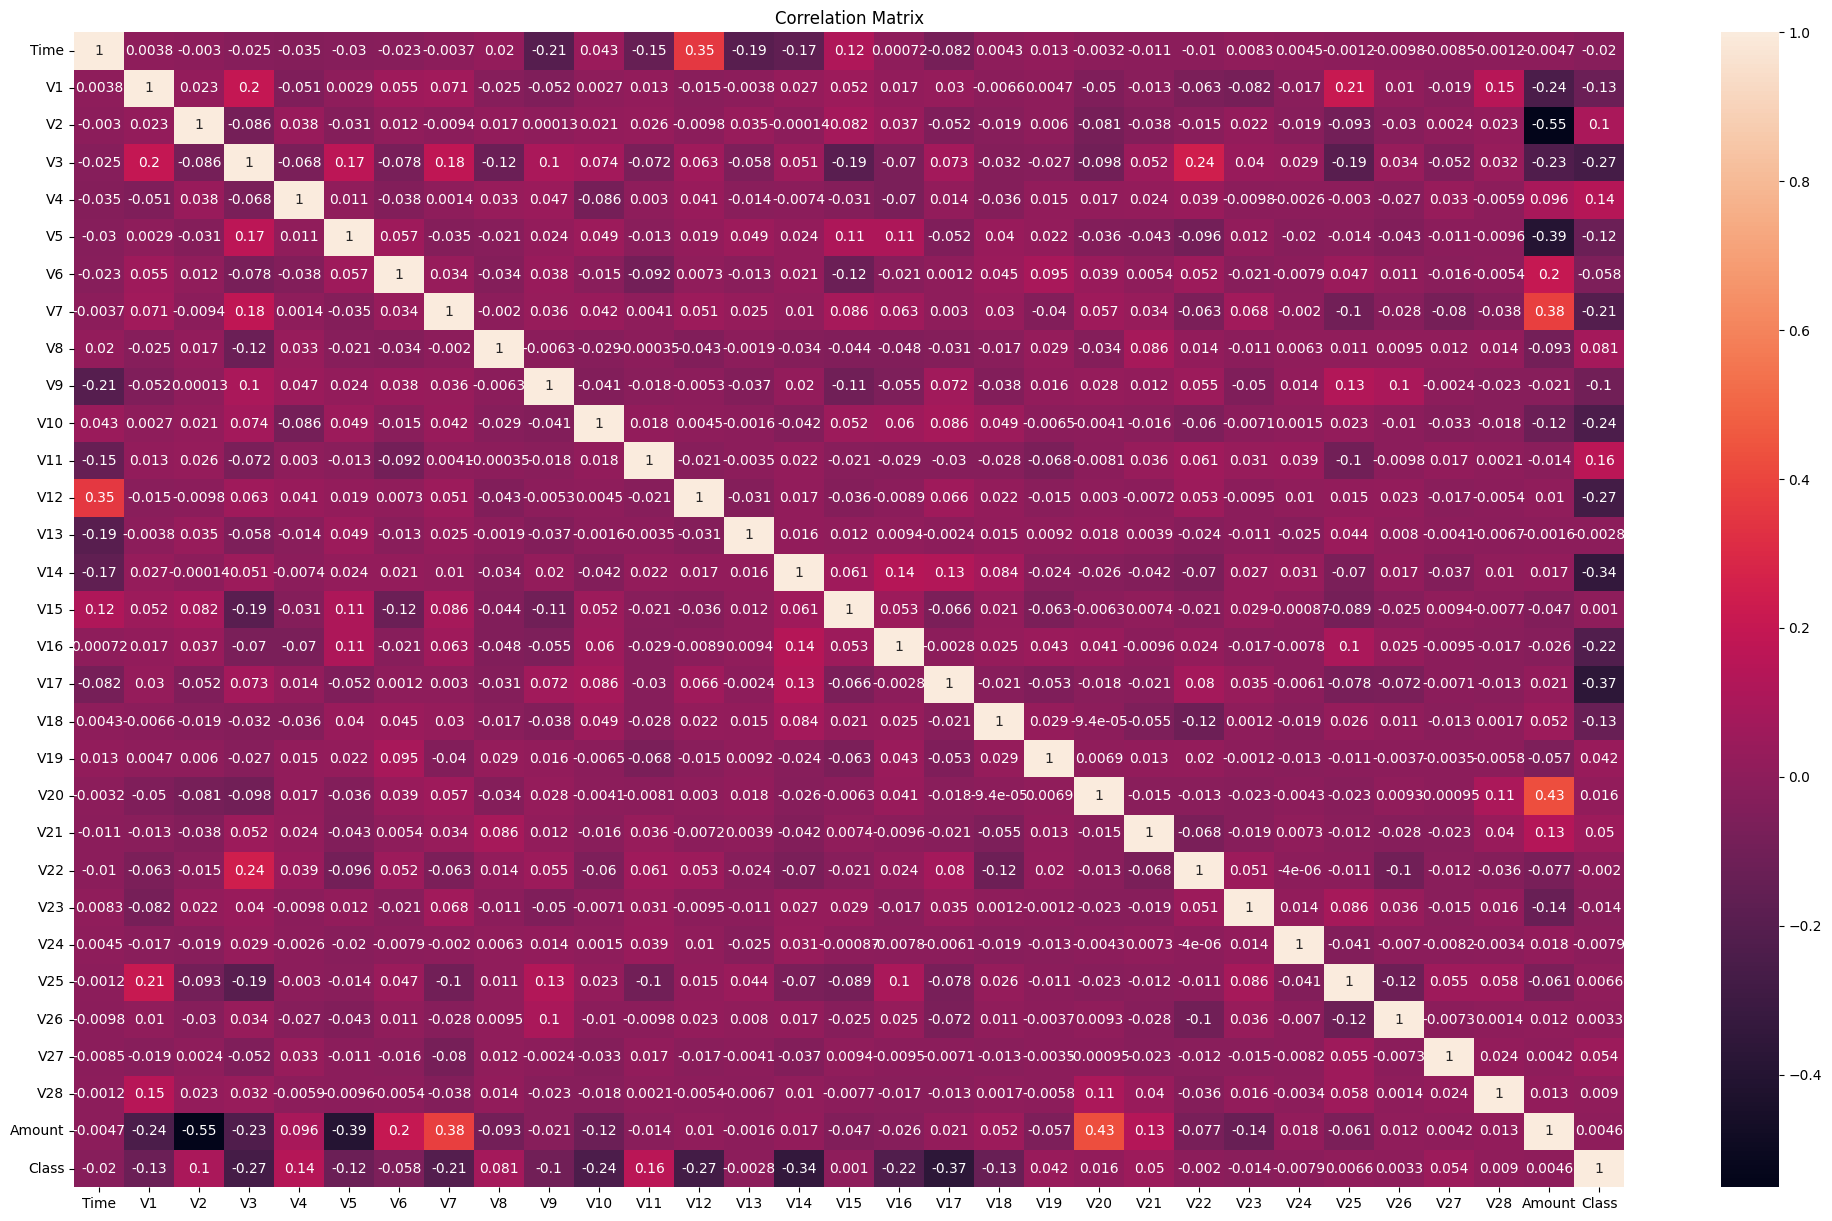

In [72]:
#Correlation Heatmap
plt.figure(figsize=(25,15))

corr = df.corr()

sns.heatmap(corr,annot=True)

plt.title("Correlation Matrix")

plt.show()

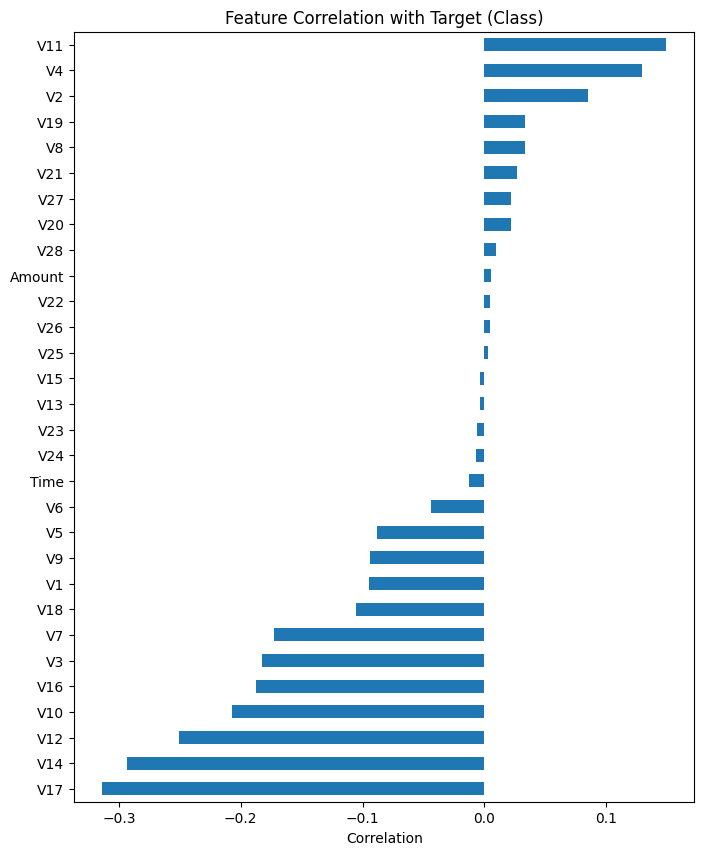

In [101]:

corr_target = df.corr()['Class'].sort_values(ascending=False)

# print(corr_target)
plt.figure(figsize=(8,10))

corr_target.drop('Class').sort_values().plot(kind='barh')

plt.title("Feature Correlation with Target (Class)")
plt.xlabel("Correlation")

plt.show()

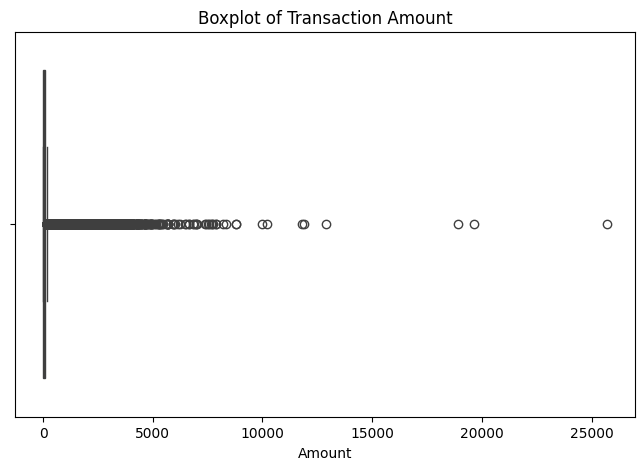

In [106]:
#Boxplot for Amount
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Amount'])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [115]:
#: Check Outliers Using the IQR Method

outlier_counts = {}

numerical_cols = df.drop(columns='Class').columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_counts[col] = outliers

outlier_df = (
    pd.DataFrame(
        outlier_counts.items(),
        columns=['Feature', 'Outlier_Count']
    )
    .sort_values(by='Outlier_Count', ascending=False)
)



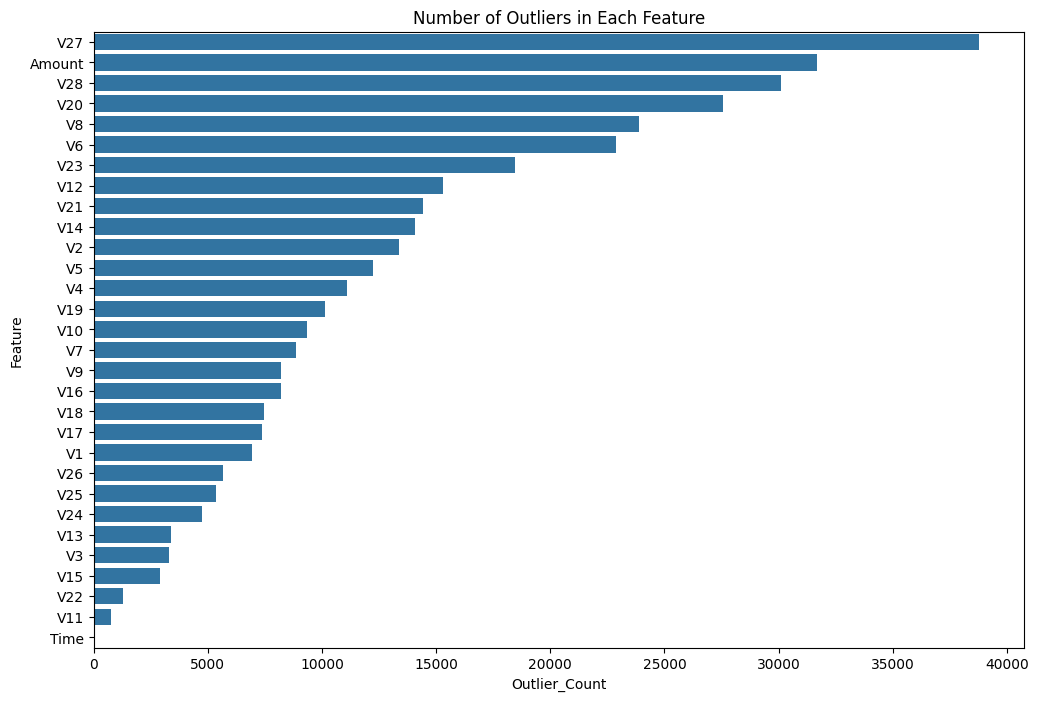

In [116]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=outlier_df,
    x='Outlier_Count',
    y='Feature'
)

plt.title("Number of Outliers in Each Feature")

plt.show()

Although several numerical features contain outliers, they were intentionally retained. In fraud detection, extreme observations may correspond to genuine fraudulent transactions, and removing them could reduce the model's ability to detect suspicious behavior.

FEATURE SELECTION

In [136]:
#Creating a working Datset
df_model = df.copy()

In [137]:
#converting time into Hours
df_model['Hour'] = df_model['Time'].apply(lambda x: x/3600)

In [138]:
df_model.drop('Time', axis=1, inplace=True)

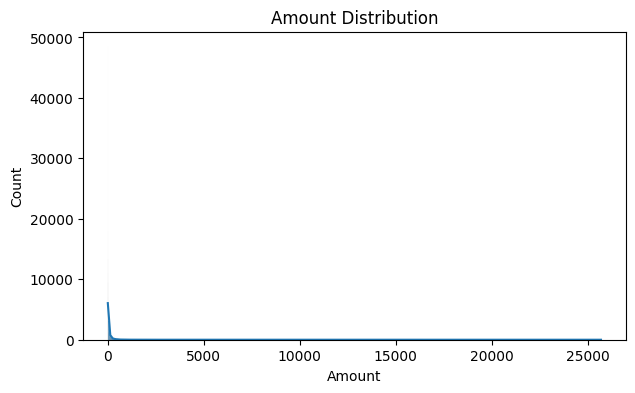

In [139]:
plt.figure(figsize=(7,4))

sns.histplot(df_model['Amount'], kde=True)

plt.title("Amount Distribution")

plt.show()

In [122]:
df_model['Log_Amount'] = np.log1p(df_model['Amount'])

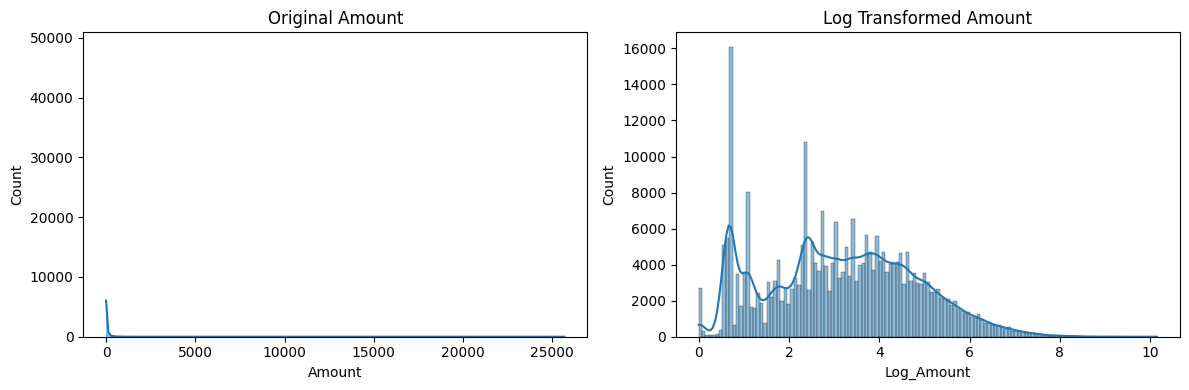

In [123]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df_model['Amount'], ax=axes[0], kde=True)
axes[0].set_title("Original Amount")

sns.histplot(df_model['Log_Amount'], ax=axes[1], kde=True)
axes[1].set_title("Log Transformed Amount")

plt.tight_layout()
plt.show()

But here we are not going to drop the original amount col because it is also necessary for model and can lern from it

In [140]:
print(df_model.info())

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      283726 non-null  float64
 1   V2      283726 non-null  float64
 2   V3      283726 non-null  float64
 3   V4      283726 non-null  float64
 4   V5      283726 non-null  float64
 5   V6      283726 non-null  float64
 6   V7      283726 non-null  float64
 7   V8      283726 non-null  float64
 8   V9      283726 non-null  float64
 9   V10     283726 non-null  float64
 10  V11     283726 non-null  float64
 11  V12     283726 non-null  float64
 12  V13     283726 non-null  float64
 13  V14     283726 non-null  float64
 14  V15     283726 non-null  float64
 15  V16     283726 non-null  float64
 16  V17     283726 non-null  float64
 17  V18     283726 non-null  float64
 18  V19     283726 non-null  float64
 19  V20     283726 non-null  float64
 20  V21     283726 non-null  float64
 21  V22     283726 

In [141]:
corr_target = df_model.corr()['Class'].sort_values(ascending=False)
print(corr_target)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Hour     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


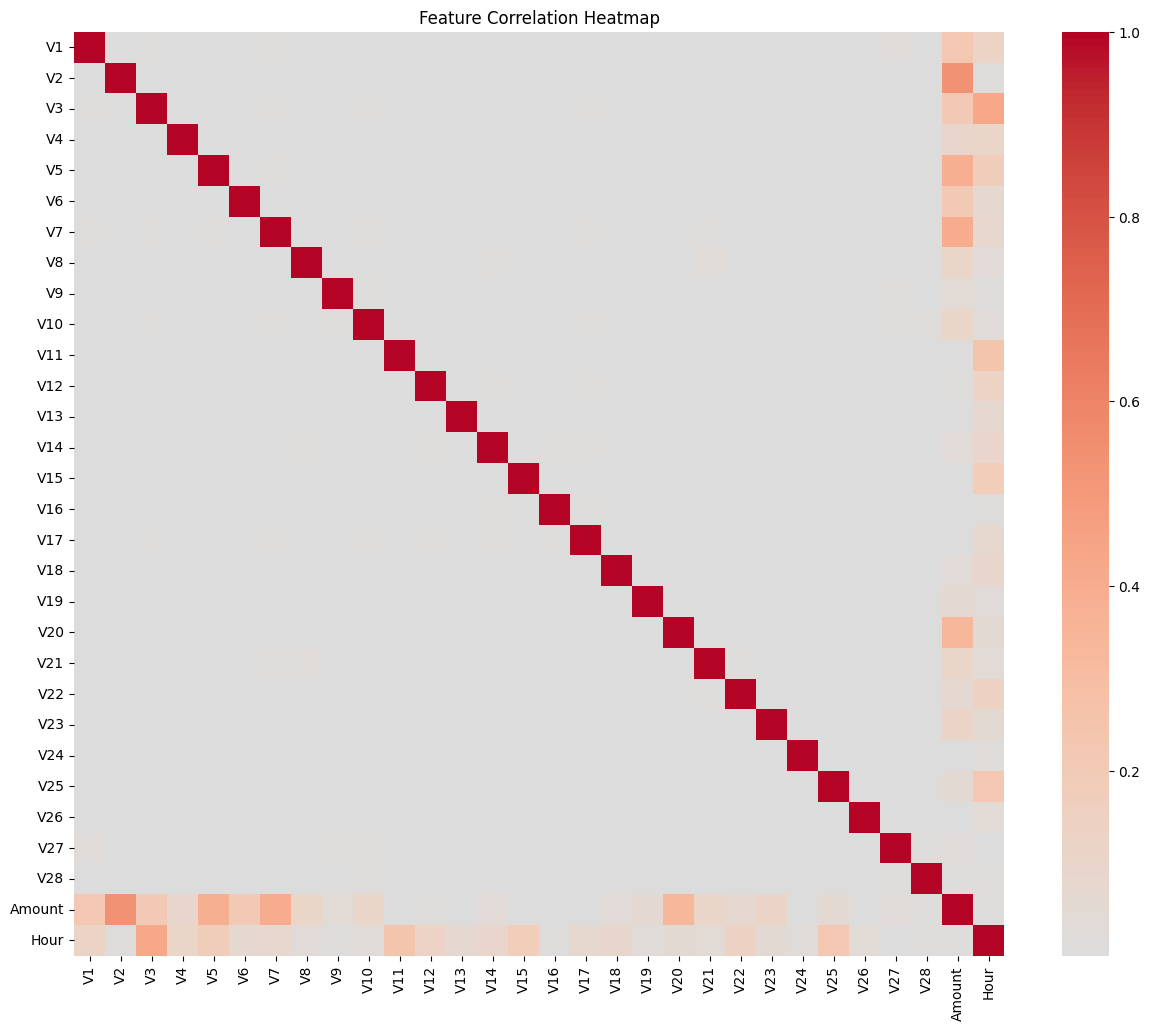

In [142]:
corr_matrix = df_model.drop('Class', axis=1).corr().abs()

plt.figure(figsize=(15,12))

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0)

plt.title("Feature Correlation Heatmap")

plt.show()

In [143]:
#Separating Features and Target
X = df_model.drop('Class', axis=1)
y = df_model['Class']

In [144]:
print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [145]:
X.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour'],
      dtype='object')

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Using stratify ensures that both the training and testing datasets have approximately the same fraud/non-fraud ratio.

In [148]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (226980, 30)
X_test : (56746, 30)
y_train: (226980,)
y_test : (56746,)


In [150]:
print("Training Set")

print(f"y_train.value_counts: {y_train.value_counts(normalize=True)*100}")

print()

print("Testing Set")

print(f"y_test.value_counts: {y_test.value_counts(normalize=True)*100}")

Training Set
y_train.value_counts: Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing Set
y_test.value_counts: Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [154]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [155]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(226980, 30)
(56746, 30)


BALANCING DATASET USING SMOTE *TECHNIQUE*

In [159]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


##MODEL BUILDING

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report


In [163]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}


In [164]:
results = []

confusion_matrices = {}

for name, model in models.items():

    print("="*60)
    print(f"Training {name}")
    print("="*60)

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Probability (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    # Save Results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc
    })

    # Save confusion matrix
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if roc is not None:
        print(f"ROC AUC  : {roc:.4f}")

    print()

Training Logistic Regression
Accuracy : 0.9737
Precision: 0.0530
Recall   : 0.8737
F1 Score : 0.1000
ROC AUC  : 0.9626

Training Decision Tree
Accuracy : 0.9975
Precision: 0.3642
Recall   : 0.6632
F1 Score : 0.4701
ROC AUC  : 0.8306

Training Random Forest
Accuracy : 0.9994
Precision: 0.8974
Recall   : 0.7368
F1 Score : 0.8092
ROC AUC  : 0.9555

Training XGBoost
Accuracy : 0.9992
Precision: 0.7282
Recall   : 0.7895
F1 Score : 0.7576
ROC AUC  : 0.9700



In [169]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.962618
1,Decision Tree,0.997498,0.364162,0.663158,0.470149,0.830608
2,Random Forest,0.999418,0.897436,0.736842,0.809249,0.955480
3,XGBoost,0.999154,0.728155,0.789474,0.757576,0.969979


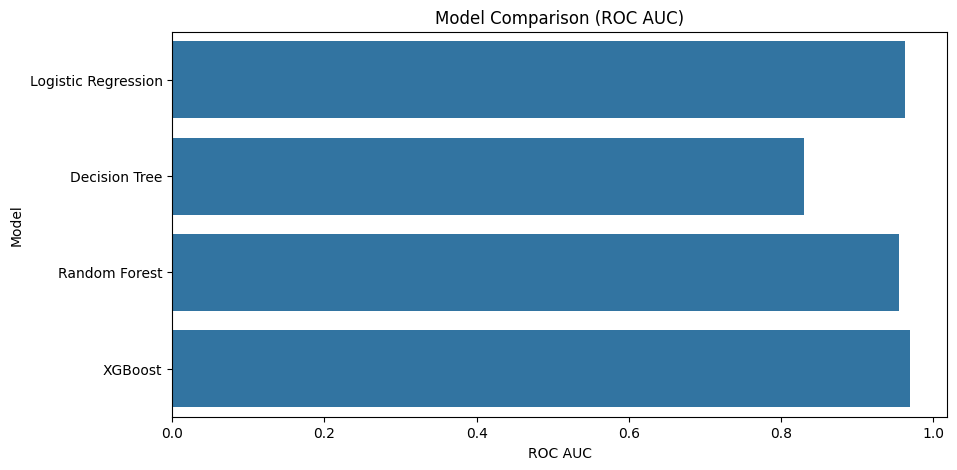

In [172]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="ROC AUC",
    y="Model"
)

plt.title("Model Comparison (ROC AUC)")
plt.show()

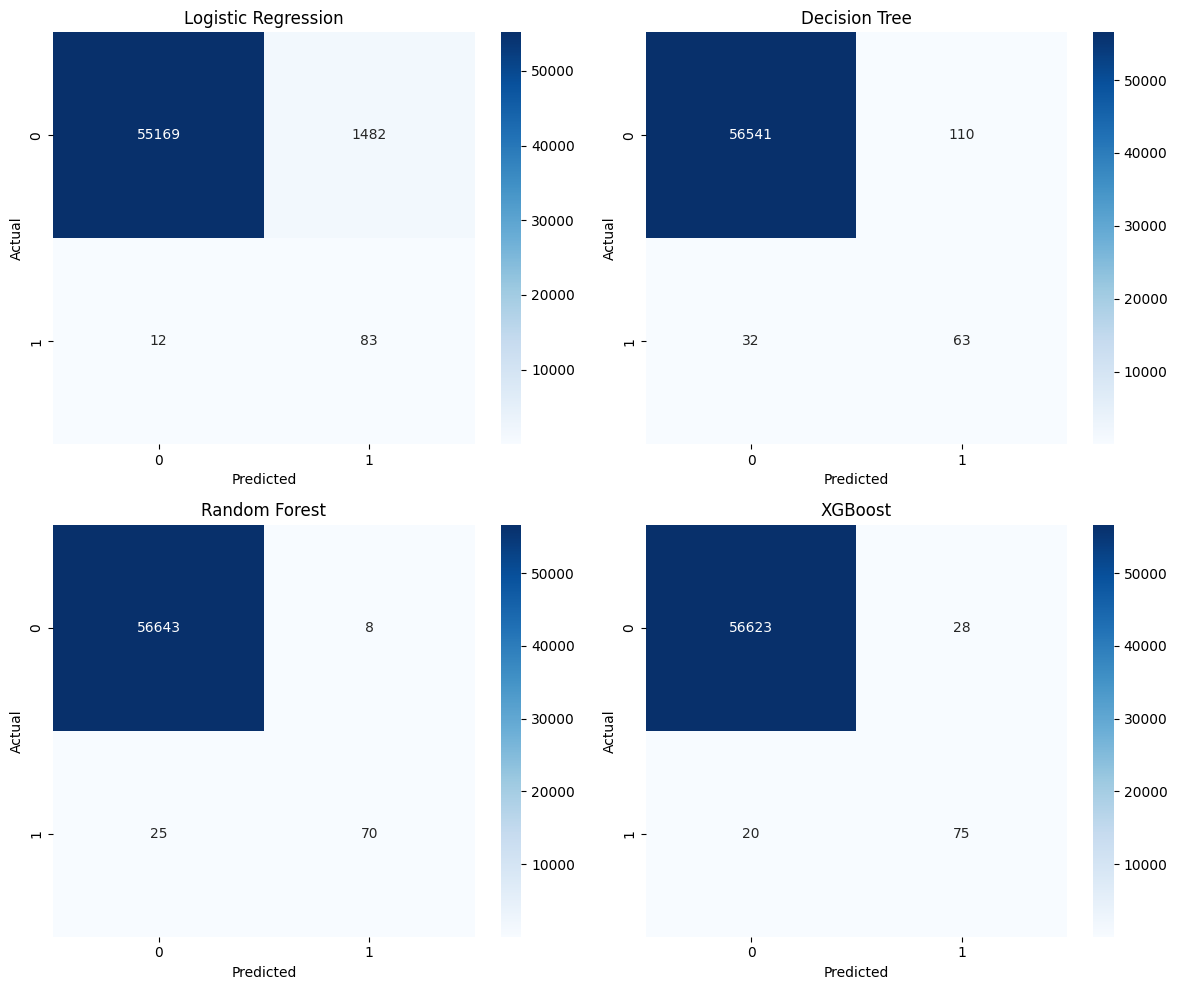

In [174]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Among all the models, Random Forest achieved the best overall performance with an Accuracy of 99.94%, Precision of 89.74%, Recall of 73.68%, and an F1-score of 80.92%, making it the most balanced and reliable model for fraud detection.**